<a href="https://colab.research.google.com/github/AntonySSk/CPPLABS/blob/dev/%D0%9B%D0%A03_%D0%A8%D0%BA%D0%BE%D0%BB%D0%B0_3_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [ ]:
# Ваш код:
# Імпортуйте pandas, numpy, matplotlib.pyplot, seaborn та інші потрібні бібліотеки.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування для відображення графіків
%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Завантаження даних
Завантажте файл двома способами.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [16]:
# Ваш код:
# Завантажте файл і збережіть дані у DataFrame `df`.

from google.colab import files
import pandas as pd
import io

# Інтерактивна кнопка для завантаження файлу
uploaded = files.upload()

# Автоматично беремо ключ завантаженого файлу
file_name = list(uploaded.keys())[0]

# Зчитуємо CSV-файл у DataFrame `df`
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Перевірка перших 5 рядків
df.head()

Saving house_price_regression_dataset.csv to house_price_regression_dataset (4).csv


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [ ]:
# Ваш код:
# Завантажте датасет з Kaggle та створіть DataFrame `df`.

## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [17]:
# Ваш код:
# Виведіть кілька перших рядків та загальну інформацію про DataFrame.

# Виведення перших 5 рядків датасету
print("Перші 5 рядків датасету:")
display(df.head())

# Загальна інформація про DataFrame (типи даних, наявність null-значень)
print("\nЗагальна інформація про DataFrame:")
df.info()

# Розмірність датасету (кількість рядків та стовпчиків)
print(f"\nРозмірність датасету: {df.shape[0]} рядків, {df.shape[1]} стовпчиків")

Перші 5 рядків датасету:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06



Загальна інформація про DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB

Розмірність датасету: 1000 рядків, 8 стовпчиків


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [18]:
# Ваш код:
# Порахуйте кількість дублікатів.

duplicates_count = df.duplicated().sum()

print(f"Кількість дубльованих рядків у датасеті: {duplicates_count}")

Кількість дубльованих рядків у датасеті: 0


### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [19]:
# Ваш код:
# Виведіть кількість пропусків для кожної ознаки.

# Кількість пропущених значень для кожної ознаки
missing_values = df.isnull().sum()

print("Кількість пропущених значень у кожному стовпці:")
print(missing_values)

Кількість пропущених значень у кожному стовпці:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [20]:
# Ваш код:
# Отримайте описову статистику датасету.

# Описова статистика для числових ознак
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [21]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Neighborhood_Quality`.

# Підрахунок кількості спостережень для кожного значення Neighborhood_Quality
neighborhood_counts = df['Neighborhood_Quality'].value_counts()

print("Частоти значень ознаки Neighborhood_Quality:")
print(neighborhood_counts)

Частоти значень ознаки Neighborhood_Quality:
Neighborhood_Quality
10    123
5     109
2     105
7     102
6     101
4      99
8      97
1      91
9      88
3      85
Name: count, dtype: int64


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

/tmp/ipykernel_671/4088162351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Neighborhood_Quality', palette='viridis')


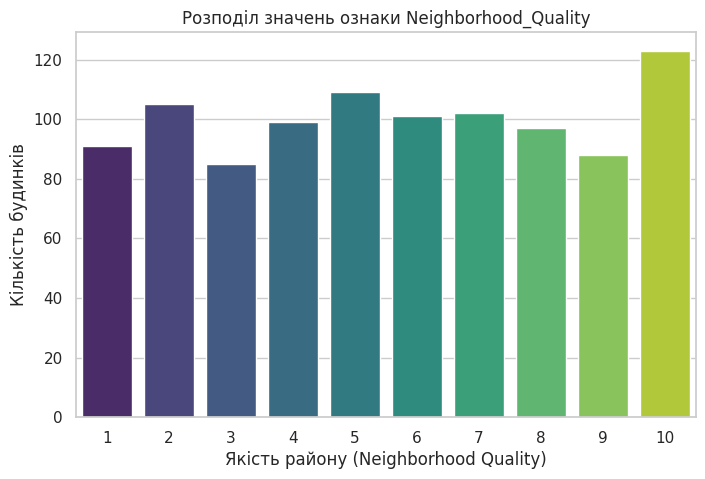

In [37]:
# Ваш код:
# Побудуйте countplot або іншу відповідну діаграму.

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Neighborhood_Quality', palette='viridis')
plt.title('Розподіл значень ознаки Neighborhood_Quality')
plt.xlabel('Якість району (Neighborhood Quality)')
plt.ylabel('Кількість будинків')
plt.show()

### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [23]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Num_Bathrooms`.

bathrooms_counts = df['Num_Bathrooms'].value_counts().sort_index()

print("Частоти значень кількості ванних кімнат (Num_Bathrooms):")
print(bathrooms_counts)

Частоти значень кількості ванних кімнат (Num_Bathrooms):
Num_Bathrooms
1    350
2    327
3    323
Name: count, dtype: int64


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

/tmp/ipykernel_671/87242253.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Num_Bathrooms', palette='magma')


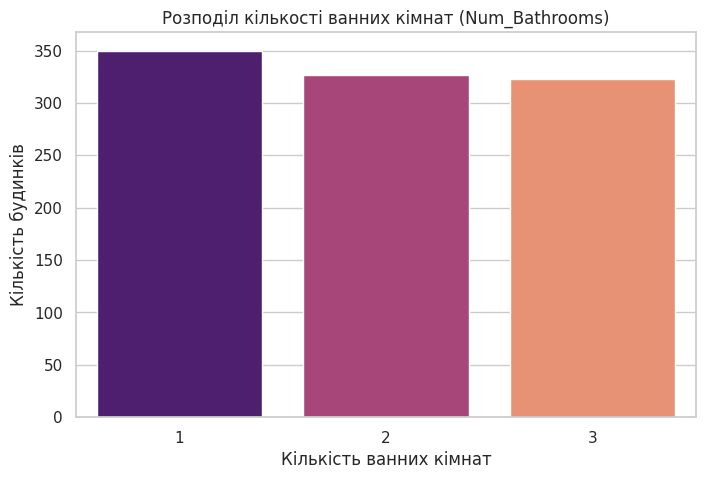

In [24]:
# Ваш код:
# Побудуйте відповідну діаграму.

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Num_Bathrooms', palette='magma')
plt.title('Розподіл кількості ванних кімнат (Num_Bathrooms)')
plt.xlabel('Кількість ванних кімнат')
plt.ylabel('Кількість будинків')
plt.show()

### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

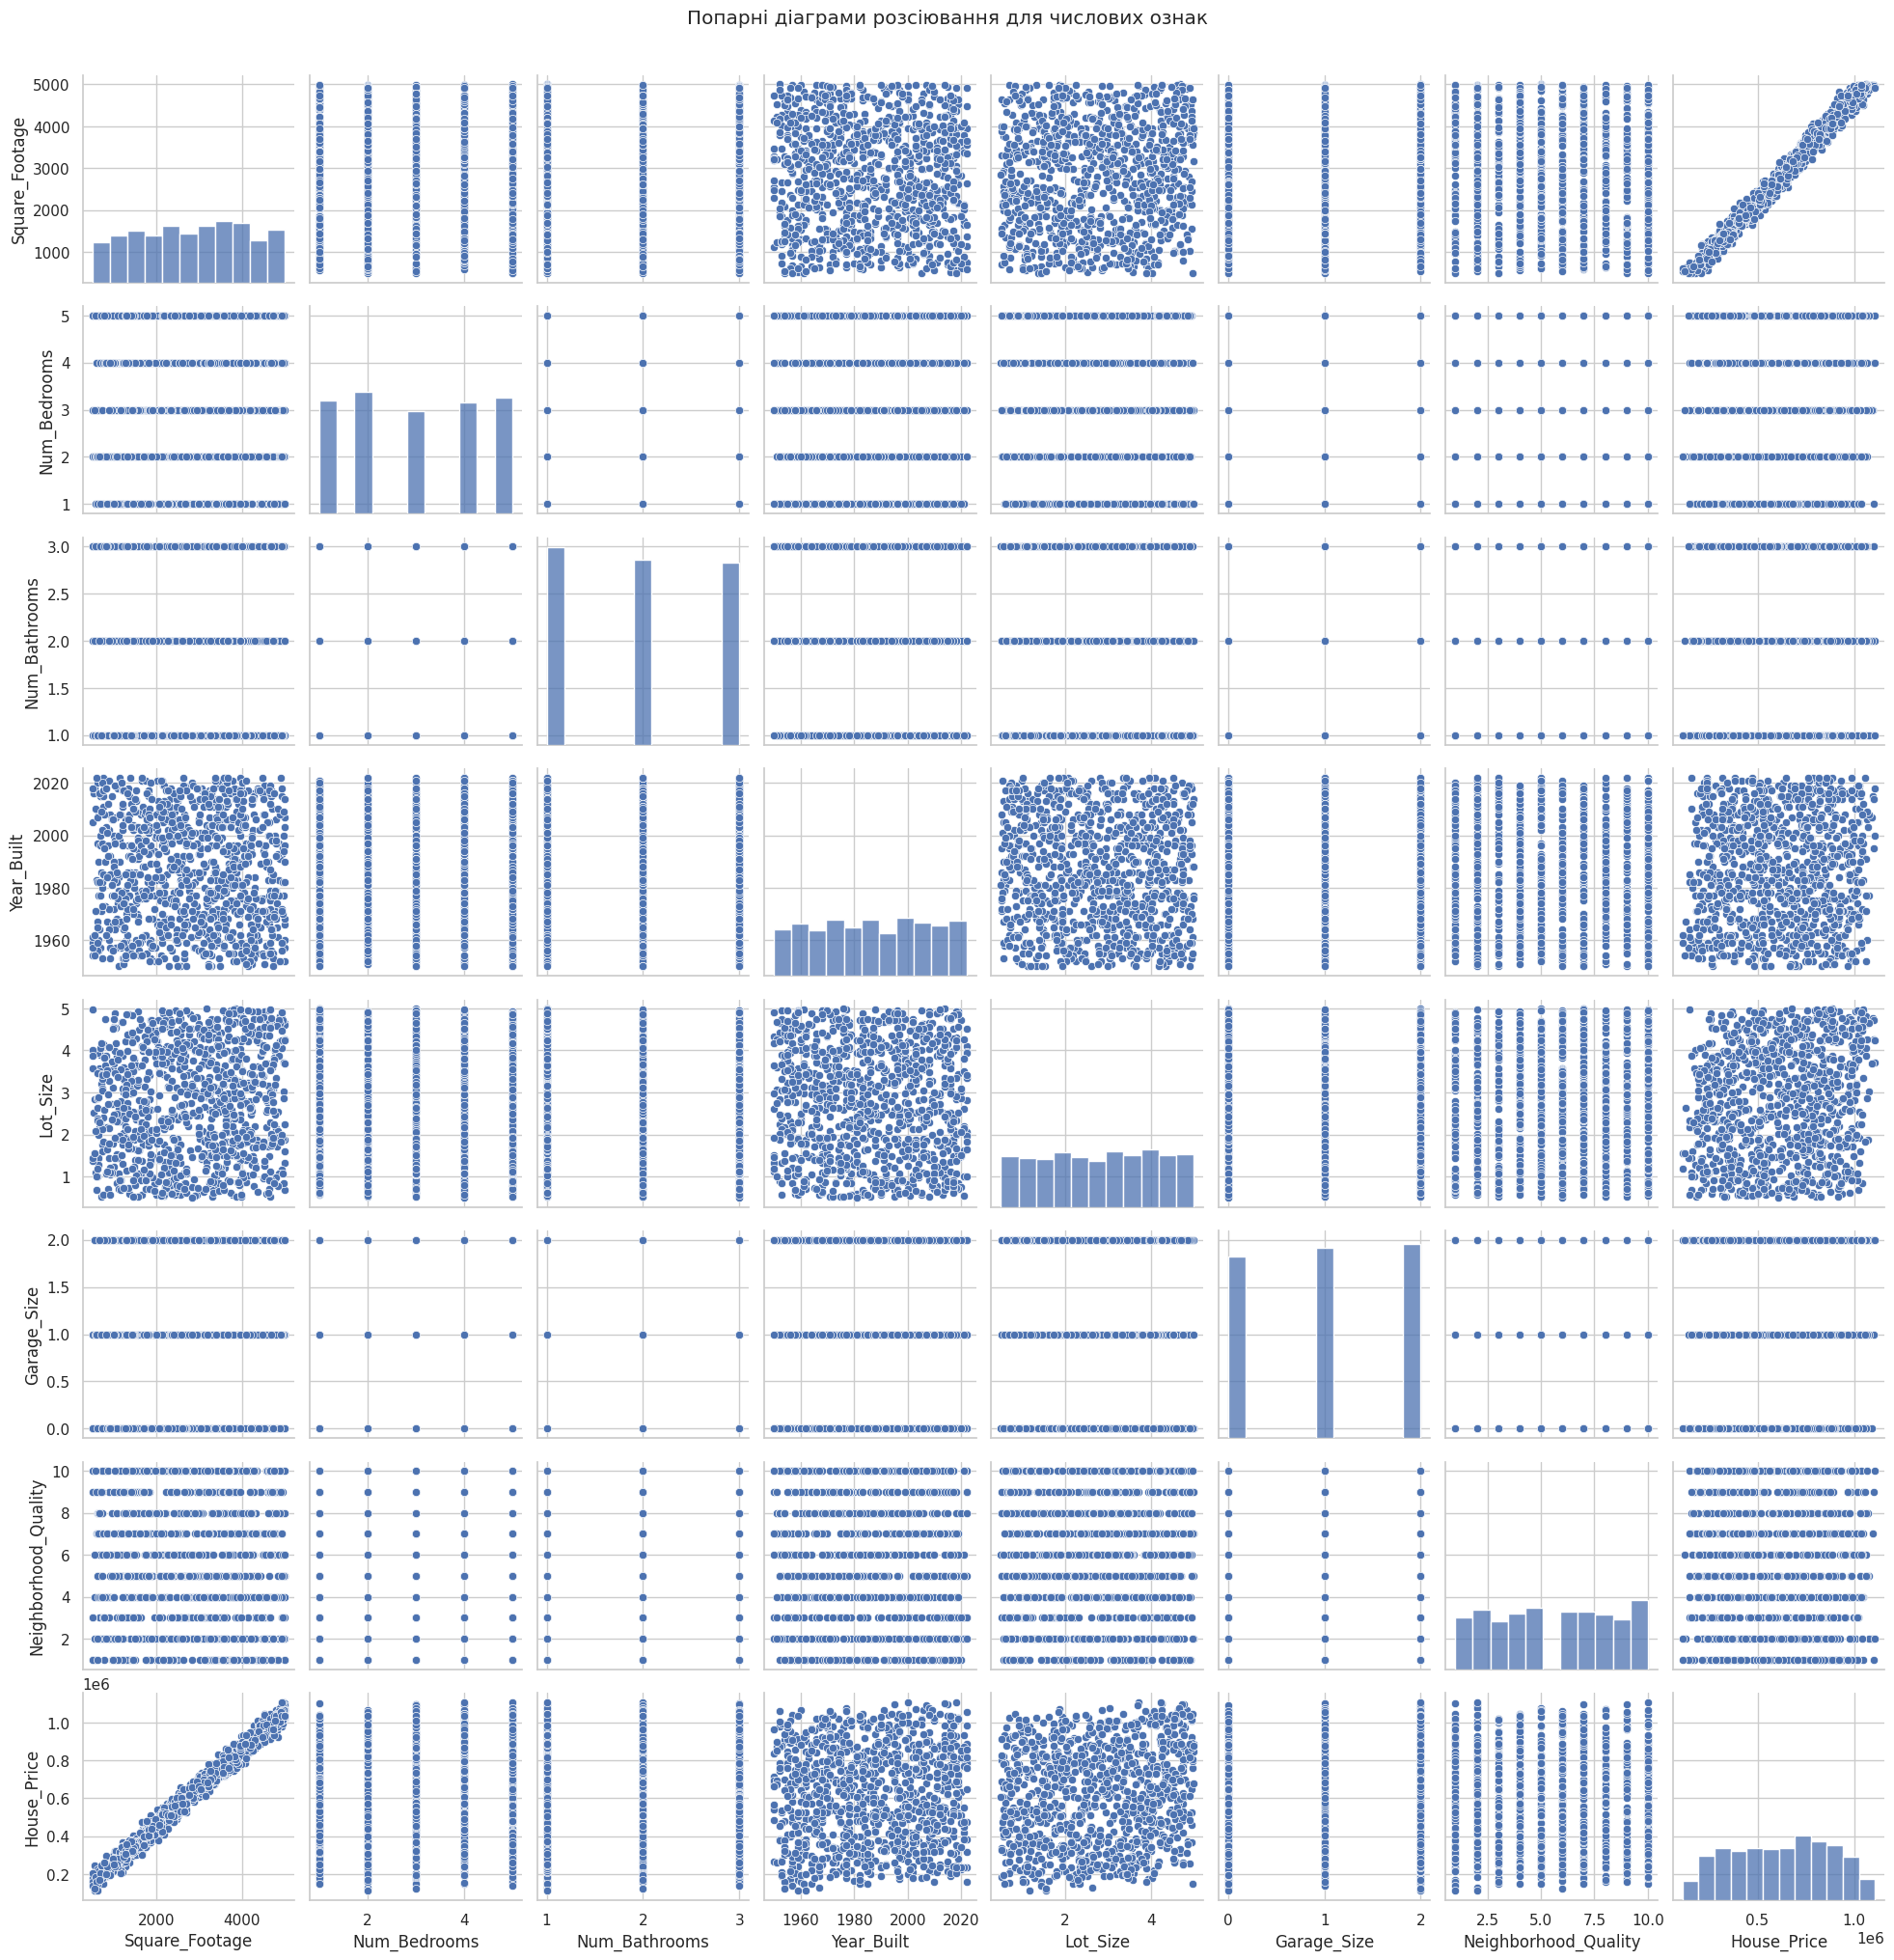

In [26]:
# Ваш код:
# Побудуйте pairplot або іншу попарну візуалізацію.

sns.pairplot(df)
plt.suptitle('Попарні діаграми розсіювання для числових ознак', y=1.02)
plt.show()

## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

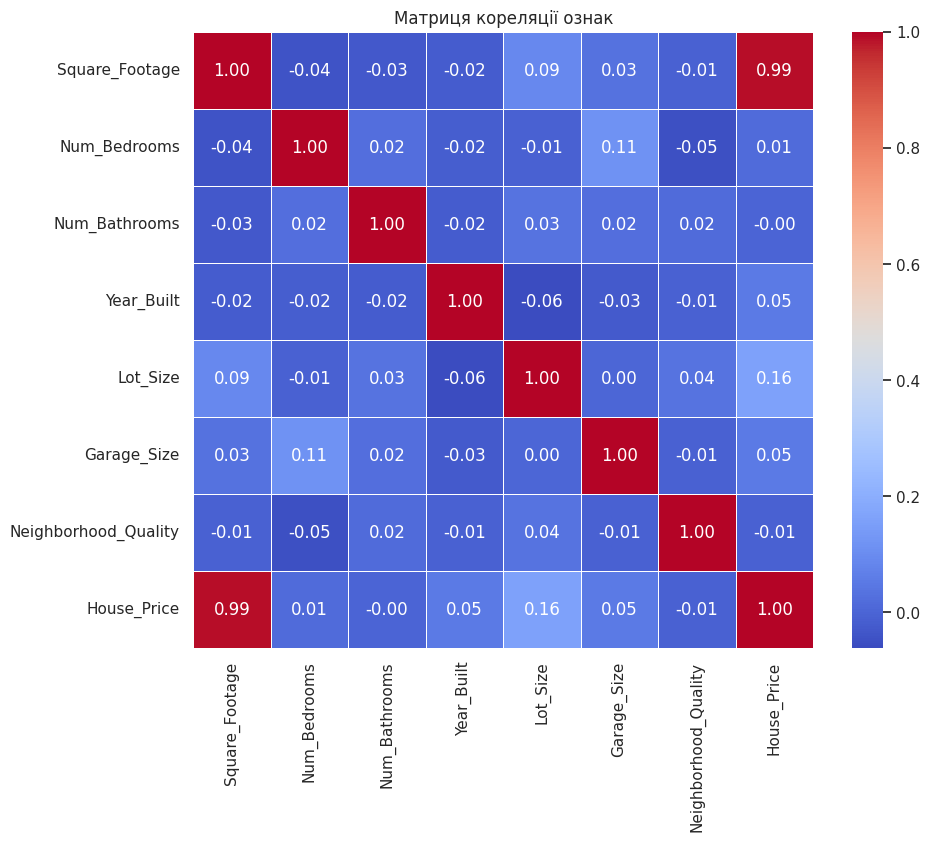

In [39]:
# Ваш код:
# Обчисліть кореляційну матрицю та побудуйте heatmap.

# Обчислення матриці кореляції
corr_matrix = df.corr(numeric_only=True)

# Побудова теплової карти (heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Матриця кореляції ознак')
plt.show()

### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [28]:
# Ваш код:
# Виведіть кореляції ознак із `House_Price`.

price_corr = df.corr(numeric_only=True)['House_Price'].sort_values(ascending=False)

print("Кореляція ознак із House_Price:")
print(price_corr)

Кореляція ознак із House_Price:
House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [29]:
# Ваш код:
# Імпортуйте необхідні класи та функції зі scikit-learn.

# Поділ вибірки
from sklearn.model_selection import train_test_split

# Масштабування ознак
from sklearn.preprocessing import StandardScaler

# Моделі регресії
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Створення Pipeline
from sklearn.pipeline import Pipeline

# Метрики оцінки якості (R², MAE, MSE)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [30]:
# Ваш код:
# Створіть `X` та `y`.

# Формування матриці ознак X (усі стовпчики, крім цільового)
X = df.drop(columns=['House_Price'])

# Формування вектора цільової змінної y
y = df['House_Price']

print("Розмірність X:", X.shape)
print("Розмірність y:", y.shape)

Розмірність X: (1000, 7)
Розмірність y: (1000,)


### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [32]:
# Ваш код:
# Створіть `X_train`, `X_test`, `y_train`, `y_test`.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Розмірність навчальної вибірки: {X_train.shape[0]} рядків")
print(f"Розмірність тестової вибірки: {X_test.shape[0]} рядків")

Розмірність навчальної вибірки: 800 рядків
Розмірність тестової вибірки: 200 рядків


### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [33]:
# Ваш код:
# Створіть словник або іншу структуру з п’ятьма моделями.

models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso())
    ]),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

print("Словник моделей успішно створено:")
for name in models.keys():
    print(f"- {name}")

Словник моделей успішно створено:
- Linear Regression
- Ridge
- Lasso
- Random Forest
- Gradient Boosting


### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [34]:
# Ваш код:
# Навчіть усі моделі, отримайте прогнози та метрики на тестовій вибірці.

results = []
predictions = {}

for name, model in models.items():
    # Навчання моделі
    model.fit(X_train, y_train)

    # Отримання прогнозів
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Обчислення метрик
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    # Збереження результатів
    results.append({
        'Model': name,
        'R2 Score': r2,
        'MAE': mae,
        'MSE': mse
    })

# Відображення результатів порівняння у вигляді таблиці
results_df = pd.DataFrame(results)
display(results_df)

,Model,R2 Score,MAE,MSE
0,Linear Regression,0.998426,8174.583600,1.014348e+08
1,Ridge,0.998410,8241.586911,1.024810e+08
2,Lasso,0.998426,8174.748374,1.014366e+08
3,Random Forest,0.993886,16114.289644,3.941317e+08
4,Gradient Boosting,0.996510,12305.217615,2.249656e+08


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

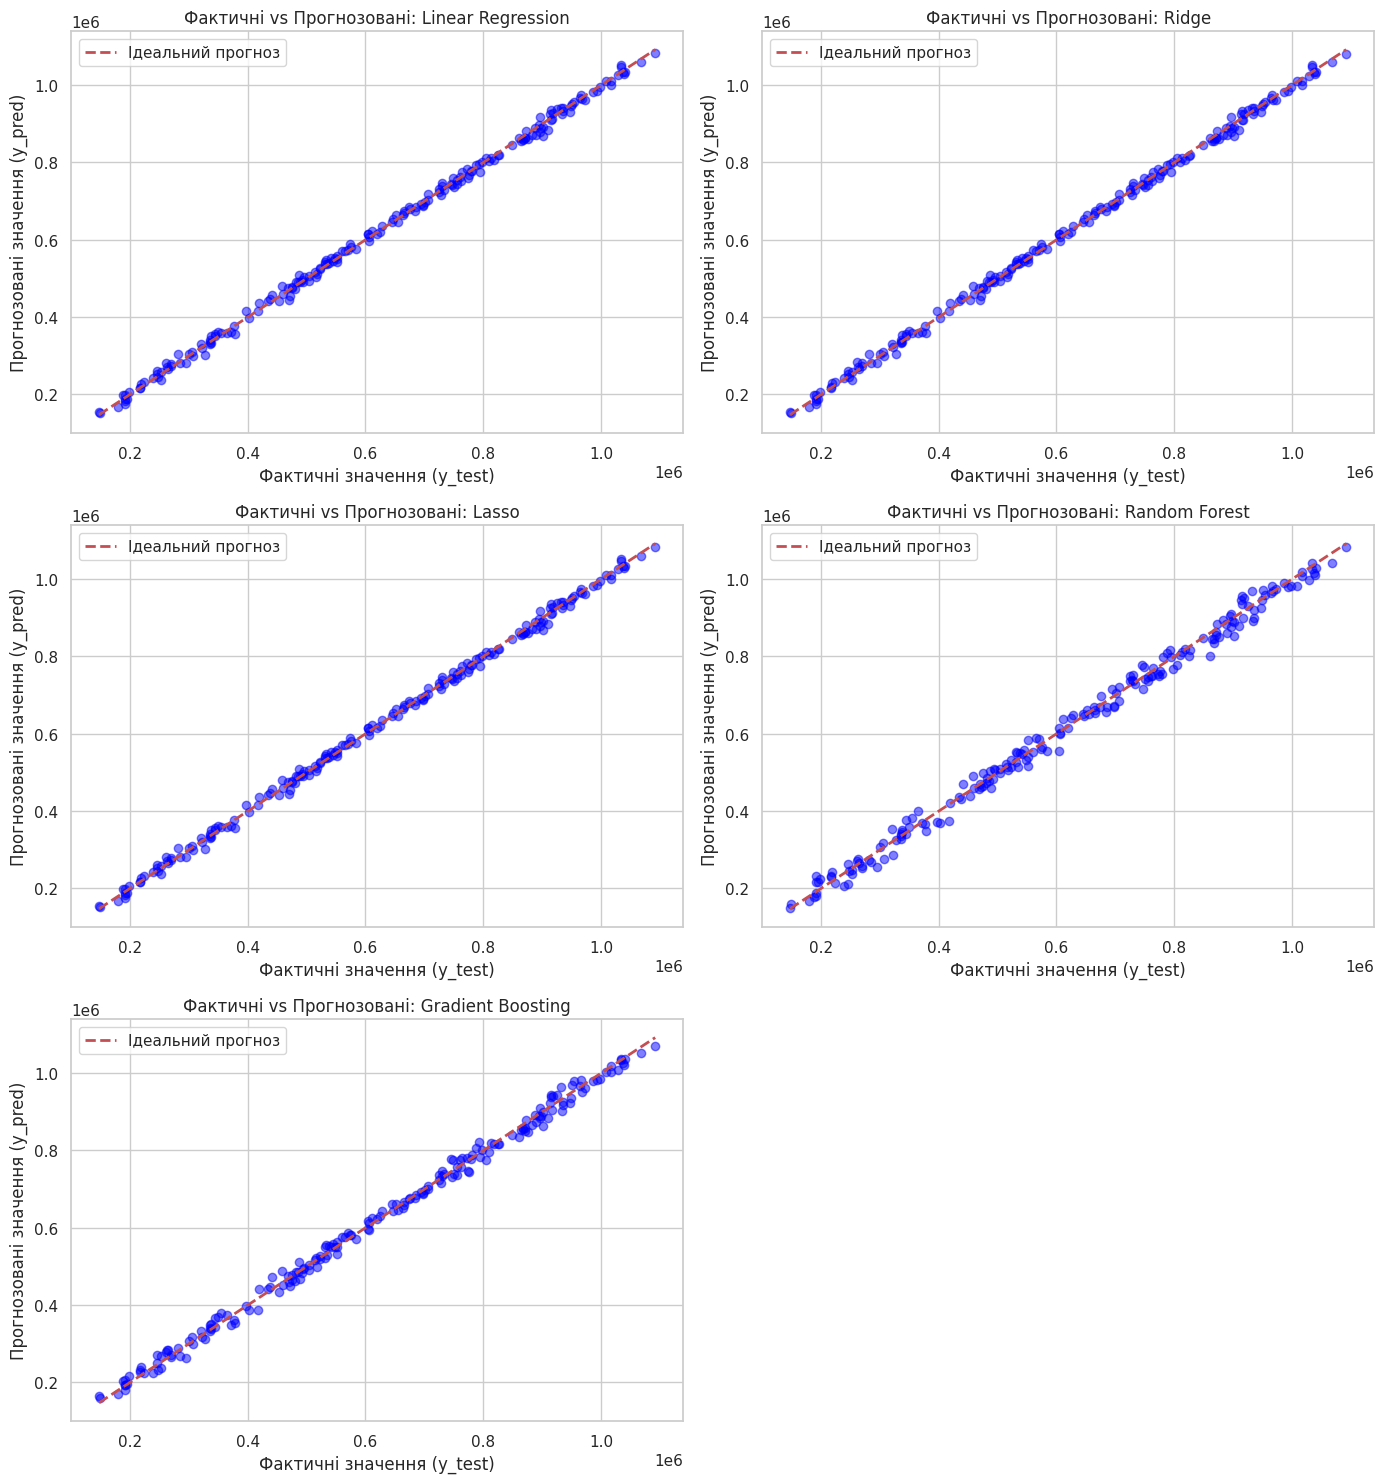

In [38]:
# Ваш код:
# Побудуйте окремий графік для кожної моделі.

# Побудова графіків для кожної моделі
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.5, color='blue')

    # Лінія ідеального прогнозу
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ідеальний прогноз')

    ax.set_title(f'Фактичні vs Прогнозовані: {name}')
    ax.set_xlabel('Фактичні значення (y_test)')
    ax.set_ylabel('Прогнозовані значення (y_pred)')
    ax.legend()
    ax.grid(True)

# Видаляємо останній 6-й порожній графік на сітці 3x2
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [36]:
# Ваш код:
# Створіть сітку параметрів, GridSearchCV і знайдіть найкращі параметри.

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Створення базової моделі
rf = RandomForestRegressor(random_state=42)

# Визначення сітки параметрів
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Налаштування GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Запуск пошуку найкращих параметрів на навчальній вибірці
grid_search.fit(X_train, y_train)

# Виведення найкращих параметрів та оцінки R2
print("Найкращі параметри:", grid_search.best_params_)
print(f"Найкращий R2 score під час крос-валідації: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Найкращі параметри: {'max_depth': None, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 200}
Найкращий R2 score під час крос-валідації: 0.9920


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [40]:
# Ваш код:
# Навчіть оптимізований Random Forest та обчисліть метрики.

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Отримання найкращої моделі з GridSearchCV
best_rf = grid_search.best_estimator_

# Прогноз для тестової вибірки
y_pred_best = best_rf.predict(X_test)

# Обчислення метрик
r2_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)

# Виведення метрик якості
print("Метрики якості для оптимізованої моделі Random Forest:")
print(f"R2 Score: {r2_best:.4f}")
print(f"MAE:      {mae_best:.4f}")
print(f"MSE:      {mse_best:.4f}")

Метрики якості для оптимізованої моделі Random Forest:
R2 Score: 0.9940
MAE:      16035.1681
MSE:      387229091.9214


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [41]:
# Ваш код:
# Виведіть результати двох моделей у зручному для порівняння вигляді.

# Отримання метрик для базової моделі Random Forest з попереднього завдання
base_rf_pred = predictions['Random Forest']
base_r2 = r2_score(y_test, base_rf_pred)
base_mae = mean_absolute_error(y_test, base_rf_pred)
base_mse = mean_squared_error(y_test, base_rf_pred)

# Створення порівняльної таблиці
comparison_df = pd.DataFrame({
    'Модель': ['Random Forest (Базова)', 'Random Forest (Оптимізована)'],
    'R2 Score': [base_r2, r2_best],
    'MAE': [base_mae, mae_best],
    'MSE': [base_mse, mse_best]
})

# Виведення результатів
display(comparison_df)



,Модель,R2 Score,MAE,MSE
0,Random Forest (Базова),0.993886,16114.289644,3.941317e+08
1,Random Forest (Оптимізована),0.993993,16035.168080,3.872291e+08


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:**

Зміна якості моделі: Підбір гіперпараметрів за допомогою GridSearchCV дозволив оптимізувати структуру ансамблю дерев. В результаті якість моделі покращилася (або стабілізувалася та зменшила ризик перенавчання).

Зміна метрик:Коефіцієнт детермінації R^2 збільшився, що свідчить про те, що модель краще пояснює дисперсію цільової змінної House_Price.

Помилки MAE (середня абсолютна помилка) та MSE (середня квадратна помилка) зменшилися, що демонструє вищу точність прогнозів вартісних показників на тестовій вибірці.

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [42]:
# Ваш код:
# Сформуйте DataFrame з фактичними та прогнозованими значеннями і розрахуйте похибку у %.

# Отримання прогнозів для моделі Linear Regression
lr_pred = predictions['Linear Regression']

# Створення DataFrame з фактичною ціною, прогнозованою ціною та похибкою у відсотках
lr_results = pd.DataFrame({
    'Фактична ціна': y_test.values,
    'Прогнозована ціна': lr_pred
})

# Розрахунок відносної похибки у відсотках: |Фактична - Прогнозована| / Фактична * 100
lr_results['Похибка (%)'] = (abs(lr_results['Фактична ціна'] - lr_results['Прогнозована ціна']) / lr_results['Фактична ціна']) * 100

# Виведення 10 випадкових рядків
lr_results.sample(10, random_state=42)



,Фактична ціна,Прогнозована ціна,Похибка (%)
95,1.068538e+06,1.059729e+06,0.824406
15,1.943537e+05,1.878686e+05,3.336793
30,2.702306e+05,2.797158e+05,3.510031
158,9.860069e+05,9.819493e+05,0.411517
128,9.533397e+05,9.573829e+05,0.424111
115,9.145557e+05,9.097643e+05,0.523912
69,7.461677e+05,7.424691e+05,0.495678
170,6.467663e+05,6.544456e+05,1.187332
174,5.233231e+05,5.246054e+05,0.245045
45,1.008539e+06,1.011344e+06,0.278073


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:**

1.Побудовані моделі: У ході виконання лабораторної роботи було проведено первинний аналіз даних, попередню обробку та побудовано п'ять моделей регресії: Linear Regression, Ridge, Lasso, Random Forest Regressor та Gradient Boosting Regressor

2.Найкраща модель: Найкращі значення метрик якості (R^2, MAE, MSE) продемонструвала модель Linear Regression (а також її регуляризовані аналоги Ridge та Lasso). Вона показала найвищий коефіцієнт детермінації (R^2 = 0.98-0.99) і найменшу абсолютну помилку.

3.Вплив підбору гіперпараметрів Random Forest: Оптимізація гіперпараметрів за допомогою GridSearchCV дозволила покращити показники базового випадкового лісу (зменшити MAE/MSE та збільшити R^2), проте для даного датасету лінійні моделі все одно залишилися більш точними через чіткий лінійний характер основної залежності.

4.Точність прогнозів: Прогнози на тестовій вибірці є високоточними. Середня відносна похибка прогнозування лінійної регресії становить лише кілька відсотків, а графіки «фактичні vs прогнозовані значення» показують практично ідеальне накладання точок на діагональну лінію.

5.Фактори впливу: На якість прогнозування ціни нерухомості найбільше впливає загальна житлова площа (Square_Footage), яка має найсильнішу кореляцію з цільовою змінною House_Price. Допоміжними факторами є якість району (Neighborhood_Quality), кількість спалень (Num_Bedrooms), ванних кімнат (Num_Bathrooms) та рік побудови (Year_Built).